# Import packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import optimize
from tqdm import tqdm

from models import model_RothC

# Model run

## Spin up

Length of time steps: 6000
Cinput_eq = 0.323  SOC = 50.000  DPM = 0.320  RPM = 6.378  BIO = 1.011  HUM = 38.071  IOM = 4.220


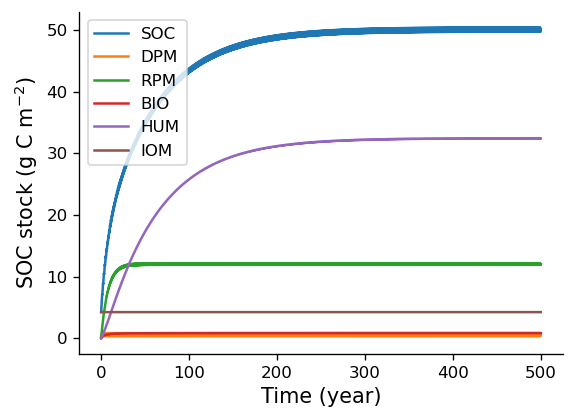

In [2]:
year_length = 500
time_steps = np.arange(1/12, year_length+0.001, 1/12)

temp_list = [-0.4, 0.3, 4.2, 8.3, 13.0, 15.9, 18.0, 17.5, 13.4, 8.7, 3.9, 0.6] * year_length
preci_list = [49, 39, 44, 41, 61, 58, 71, 58, 51, 48, 50, 58] * year_length
evp_list = [12, 18, 35, 58, 82, 90, 97, 84, 54, 31, 14, 10] * year_length

# temp_list = [temp + 10 for temp in temp_list]

soil_depth = 25
bare = False
soc = 50
clay = 48
DR = 1.44
IOM = 0.049 * soc**1.139
c_input = 0.323  # monthly C input
use_mic_adj_decay = False
k_mic_half = 0.409
k_mic_adj_max = 3

print('Length of time steps: {}'.format(len(time_steps)))

model_rothc = model_RothC.RothCModel()
res = model_rothc.spin_up(time_steps=time_steps,
                          c_input=c_input, DPM=0, RPM=0, BIO=0, HUM=0, IOM=IOM, SOC_eq=soc,
                          temp=temp_list, preci=preci_list, evp=evp_list, clay=clay, soil_depth=soil_depth, bare=bare, vege_cover=None, fPR=None, DR=DR,
                          k_DPM=10, k_RPM=0.3, k_BIO=0.66, k_HUM=0.02, k_IOM=0,
                          use_mic_adj_decay=use_mic_adj_decay, k_mic_half=k_mic_half, k_mic_adj_max=k_mic_adj_max,
                          show_info=True, plot=True)
c_input_ss, SOC_ss, DPM_ss, RPM_ss, BIO_ss, HUM_ss, IOM_ss = res[0], res[1], res[2], res[3], res[4], res[5], res[6]

# Forward run model

In [3]:
### Forward run model

year_length = 30
time_steps = np.arange(1/12, year_length+0.001, 1/12)

c_input_list = [c_input_ss * 1 for i in range(len(time_steps))]
# c_input_list = [c_input_ss * (1+i*0.0001) for i in range(len(time_steps))]

temp_list_ss = np.array([-0.4, 0.3, 4.2, 8.3, 13.0, 15.9, 18.0, 17.5, 13.4, 8.7, 3.9, 0.6])
temp_list_forward = []
for i in range(year_length):
    temp_list_forward.extend(temp_list_ss + (i*0.1))

preci_list_forward = [49, 39, 44, 41, 61, 58, 71, 58, 51, 48, 50, 58] * year_length
evp_list_forward = [12, 18, 35, 58, 82, 90, 97, 84, 54, 31, 14, 10] * year_length

print(len(time_steps))

model = model_RothC.RothCModel()
res = model.forward(
    time_steps=time_steps,
    c_inputs=c_input_list, DPM=DPM_ss, RPM=RPM_ss, BIO=BIO_ss, HUM=HUM_ss, IOM=IOM_ss,
    temp=temp_list_forward, preci=preci_list_forward, evp=evp_list_forward, clay=clay, soil_depth=soil_depth, bare=bare, vege_cover=None, fPR=None, DR=DR,
    k_DPM=10, k_RPM=0.3, k_BIO=0.66, k_HUM=0.02, k_IOM=0,
    use_mic_adj_decay=use_mic_adj_decay, k_mic_half=k_mic_half, k_mic_adj_max=k_mic_adj_max,
    plot=False
)
soc_list, DPM_list, RPM_list, BIO_list, HUM_list, IOM_list, CO2_list = res[0], res[1], res[2], res[3], res[4], res[5], res[6]

360


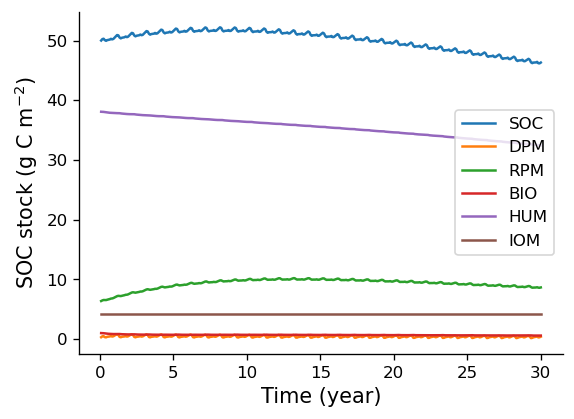

In [4]:
line_width = 1.5
plt.figure(figsize=(5.2, 3.7), dpi=120)
plt.plot(time_steps, soc_list, label='SOC', linewidth=line_width)
plt.plot(time_steps, DPM_list, label='DPM', linewidth=line_width)
plt.plot(time_steps, RPM_list, label='RPM', linewidth=line_width)
plt.plot(time_steps, BIO_list, label='BIO', linewidth=line_width)
plt.plot(time_steps, HUM_list, label='HUM', linewidth=line_width)
plt.plot(time_steps, IOM_list, label='IOM', linewidth=line_width)
plt.legend()
plt.xlabel('Time (year)', fontsize=12.5)
plt.ylabel('SOC stock (g C m$^{-2}$)', fontsize=12.5)
sns.despine()
plt.show()